# AML s26 -  LDA vs QDA comparison

### Import libraries 

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

---
### Load Data and take a subset 

In [61]:
df_all = pd.read_csv('data_da.csv')

use_all = False
sample_n = 500

if use_all:
    df = df_all.copy()
else:
    df = df_all.sample(n=sample_n)

X = df[['feature_1', 'feature_2']].values
y = df['label'].values

CLASS_NAMES = [f'Class {k}' for k in range(4)]
COLORS      = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
MARKERS     = ['o', 's', '^', 'D']

print(f'Loaded {len(df)} samples')
print(f'Class distribution: { {int(k): int((y==k).sum()) for k in range(4)} }')
df.head()

Loaded 500 samples
Class distribution: {0: 122, 1: 129, 2: 127, 3: 122}


,feature_1,feature_2,label
714,-3.387154,0.924358,3
433,3.399796,3.036844,2
397,4.791322,-2.272321,1
685,-2.828054,4.442104,3
251,1.531004,-4.746124,1


---
### Train / Test Split and Fit Classifiers

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

lda.fit(X_train, y_train)
qda.fit(X_train, y_train)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print()
print(f'LDA  train | test accuracy: {lda.score(X_train, y_train):.4f}  |  {lda.score(X_test, y_test):.4f}')
print(f'QDA  train | test accuracy: {qda.score(X_train, y_train):.4f}  |  {qda.score(X_test, y_test):.4f}')

Training samples : 375
Test samples     : 125

LDA  train | test accuracy: 0.9520  |  0.9360
QDA  train | test accuracy: 0.9733  |  0.9760


---
###  Decision Boundary Comparison

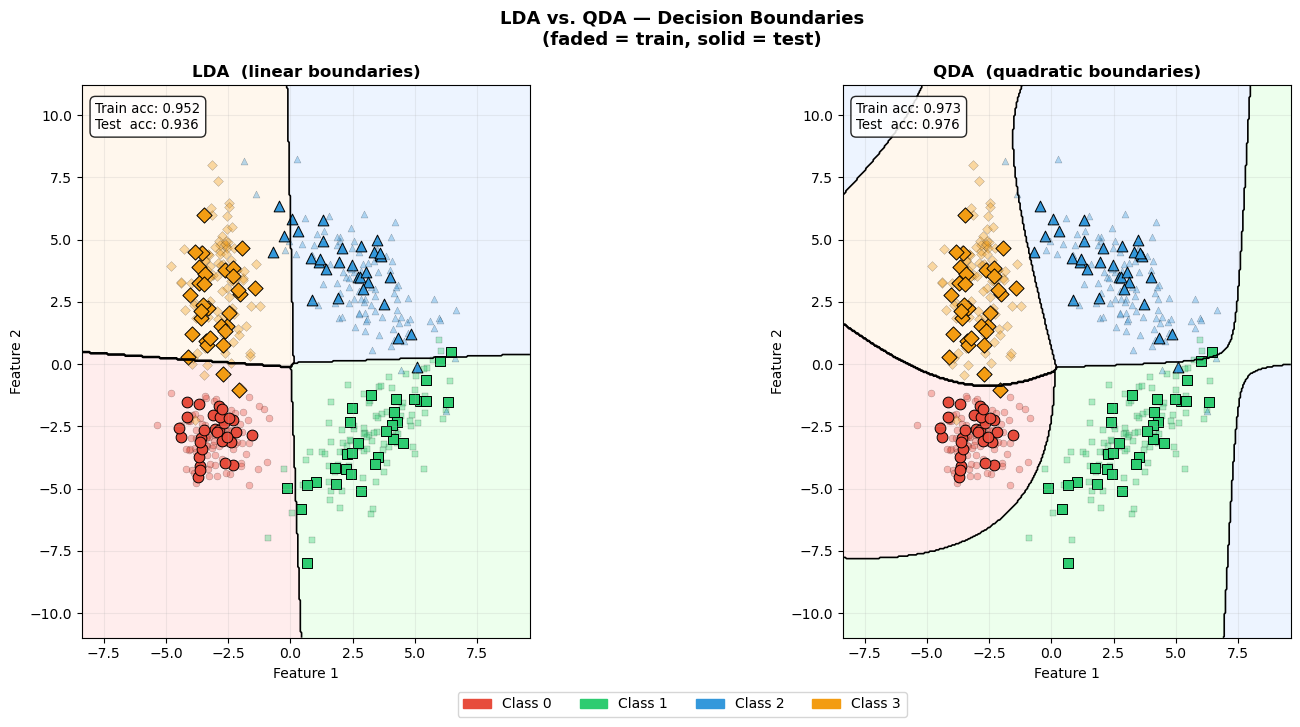

In [63]:
def plot_decision_boundary(ax, clf, X_tr, y_tr, X_te, y_te, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 3.0, X[:, 0].max() + 3.0
    y_min, y_max = X[:, 1].min() - 3.0, X[:, 1].max() + 3.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    bg  = ListedColormap(['#ffcccc', '#ccffcc', '#cce0ff', '#ffeacc'])
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=bg, levels=[-0.5, 0.5, 1.5, 2.5, 3.5])
    ax.contour( xx, yy, Z, levels=[0.5, 1.5, 2.5], colors='black', linewidths=1.2)

    # Training points (faded)
    for k in range(4):
        mask = y_tr == k
        ax.scatter(X_tr[mask, 0], X_tr[mask, 1],
                   c=COLORS[k], marker=MARKERS[k], s=25,
                   edgecolors='k', linewidths=0.3, alpha=0.35)

    # Test points (solid)
    for k in range(4):
        mask = y_te == k
        ax.scatter(X_te[mask, 0], X_te[mask, 1],
                   c=COLORS[k], marker=MARKERS[k], s=60,
                   edgecolors='k', linewidths=0.7, alpha=1.0)

    acc_tr = clf.score(X_tr, y_tr)
    acc_te = clf.score(X_te, y_te)
    ax.text(0.03, 0.97, f'Train acc: {acc_tr:.3f}\nTest  acc: {acc_te:.3f}',
            transform=ax.transAxes, fontsize=9.5, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=10)
    ax.set_ylabel('Feature 2', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('LDA vs. QDA — Decision Boundaries\n'
             '(faded = train, solid = test)', fontsize=13, fontweight='bold')

plot_decision_boundary(axes[0], lda, X_train, y_train, X_test, y_test, 'LDA  (linear boundaries)')
plot_decision_boundary(axes[1], qda, X_train, y_train, X_test, y_test, 'QDA  (quadratic boundaries)')

handles = [mpatches.Patch(color=COLORS[k], label=CLASS_NAMES[k]) for k in range(4)]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

**What to notice:** LDA draws straight-line boundaries — it cannot adapt to the differently shaped clusters. QDA's curved boundaries wrap more tightly around each cluster.

---
### Posterior Probability Maps

Show `P(Y=k | X=x)` across the feature space for each model

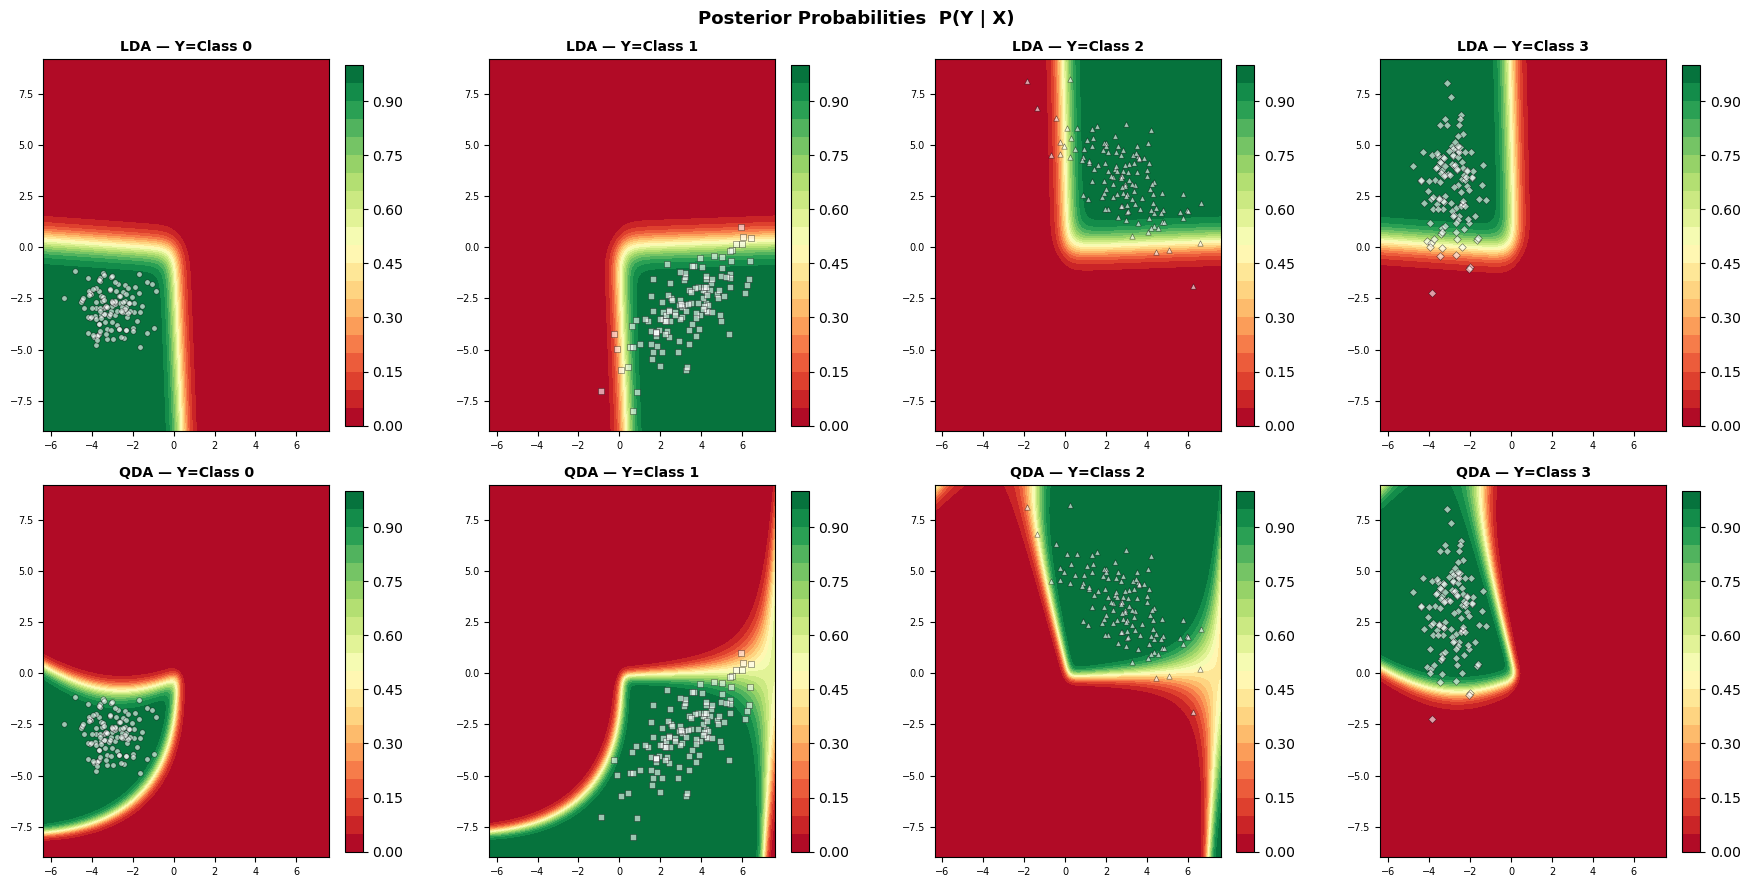

In [64]:
h = 0.06
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),   np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Posterior Probabilities  P(Y | X)',  fontsize=13, fontweight='bold')

for row, (clf, clf_name) in enumerate([(lda, 'LDA'), (qda, 'QDA')]):
    proba = clf.predict_proba(grid)
    for k in range(4):
        ax = axes[row, k]
        Z = proba[:, k].reshape(xx.shape)
        im = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', vmin=0, vmax=1)
        mask = y == k
        ax.scatter(X[mask, 0], X[mask, 1],  c='white', marker=MARKERS[k], s=15, edgecolors='black', linewidths=0.4, alpha=0.6)
        ax.set_title(f'{clf_name} — Y={CLASS_NAMES[k]}', fontsize=10, fontweight='bold')
        ax.set_aspect('equal')
        ax.tick_params(labelsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

---
### Show Confusion Matrices

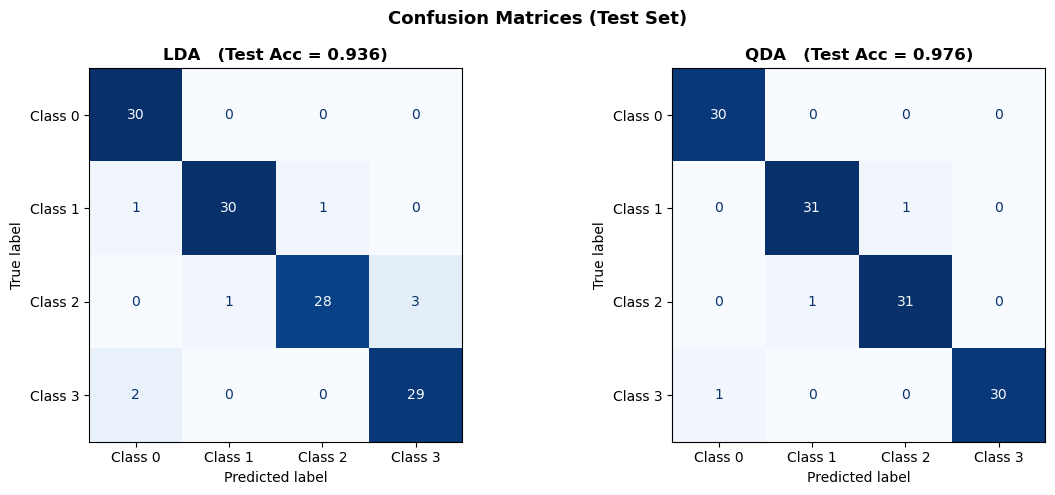

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

for ax, clf, name in zip(axes, [lda, qda], ['LDA', 'QDA']):
    cm = confusion_matrix(y_test, clf.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}   (Test Acc = {clf.score(X_test, y_test):.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

---
### Generate Per-Class Classification Report

In [66]:
for clf, name in [(lda, 'LDA'), (qda, 'QDA')]:
    print('-' * 55)
    print(f'  {name} — Classification Report')
    print('-' * 55)
    print(classification_report(y_test, clf.predict(X_test),
                                 target_names=CLASS_NAMES))

-------------------------------------------------------
  LDA — Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.91      1.00      0.95        30
     Class 1       0.97      0.94      0.95        32
     Class 2       0.97      0.88      0.92        32
     Class 3       0.91      0.94      0.92        31

    accuracy                           0.94       125
   macro avg       0.94      0.94      0.94       125
weighted avg       0.94      0.94      0.94       125

-------------------------------------------------------
  QDA — Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

     Class 0       0.97      1.00      0.98        30
     Class 1       0.97      0.97      0.97        32
     Class 2       0.97      0.97      0.97        32
     Class 3       1.00      0.97      0.98        31

    accur